# 03 — Khai phá Tri thức (Mining)

**Nội dung bắt buộc:**
1. **Luật kết hợp (Association Rules)** — Apriori: tìm pattern liên quan bệnh tim
2. **Phân cụm (Clustering)** — K-Means (Elbow + Silhouette) & DBSCAN
3. **Phát hiện ngoại lệ (Anomaly Detection)** — Isolation Forest

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.dirname(os.getcwd()))

from src import load_params
from src.data.loader import load_raw_data
from src.data.cleaner import run_cleaning_pipeline
from src.mining.association import mine_rules
from src.mining.clustering import run_clustering
from src.mining.anomaly import detect_anomalies

params = load_params()

In [2]:
# Chuẩn bị dữ liệu
df_raw = load_raw_data(params)
prep = run_cleaning_pipeline(df_raw, params)

[LOADER] Đọc thành công: 920 dòng × 16 cột

TIỀN XỬ LÝ DỮ LIỆU
[CLEANER] Xử lý missing xong. Còn thiếu: 0
[CLEANER] Nhị phân hóa target: {1: 509, 0: 411}
[CLEANER] Mã hóa 7 biến phân loại
[CLEANER] Tách train/test: Train=736, Test=184
  Train: {1: 407, 0: 329}
  Test:  {1: 102, 0: 82}
[CLEANER] Chuẩn hóa 6 biến số (StandardScaler)
[CLEANER] Chuẩn hóa 6 biến số (StandardScaler)
[CLEANER] SMOTE: 736 → 814 mẫu
  Phân bố sau: {1: 407, 0: 407}
[CLEANER] Đã lưu dữ liệu processed → c:\KHMT\BTL-DATAMINING\data/processed


## 3.1 Luật kết hợp (Apriori)

Rời rạc hóa biến số → Transaction → Apriori → Luật kết hợp  
Lọc luật liên quan đến bệnh tim (consequent = has_disease / no_disease)

In [3]:
rules = mine_rules(prep["df_clean"], params)


--- LUẬT KẾT HỢP (Apriori) ---
  Tập phổ biến: 1318 (min_support=0.1)
  Luật kết hợp: 5671 (min_confidence=0.6)
  Liên quan bệnh tim: 1107

  Top 10 luật (theo Lift):
    atypical angina, False → flat, no_disease, normal  [sup=0.117, conf=0.635, lift=2.231]
    atypical angina → flat, no_disease, normal, False  [sup=0.117, conf=0.621, lift=2.222]
    atypical angina → flat, no_disease, normal  [sup=0.118, conf=0.626, lift=2.200]
    atypical angina, normal, False → flat, no_disease  [sup=0.117, conf=0.647, lift=2.187]
    atypical angina, normal → flat, no_disease, False  [sup=0.117, conf=0.632, lift=2.176]
    atypical angina, normal → flat, no_disease  [sup=0.118, conf=0.637, lift=2.156]
    atypical angina, False → flat, no_disease  [sup=0.117, conf=0.635, lift=2.149]
    atypical angina → flat, no_disease, False  [sup=0.117, conf=0.621, lift=2.139]
    atypical angina → flat, no_disease  [sup=0.118, conf=0.626, lift=2.119]
    flat, atypical angina, False → no_disease, normal  [su

### Diễn giải Apriori

**Ý nghĩa các chỉ số:**
- **Support** = tỷ lệ giao dịch chứa tổ hợp → tổ hợp triệu chứng phổ biến
- **Confidence** = P(consequent | antecedent) → xác suất mắc bệnh khi có tổ hợp triệu chứng
- **Lift > 1** = tổ hợp xuất hiện nhiều hơn so với ngẫu nhiên → **mối liên hệ thực sự**
- **Lift > 2** = mối liên hệ rất mạnh, cần ưu tiên sàng lọc

**Ứng dụng y khoa:**
- Luật có consequent = `has_disease` + lift cao → **tổ hợp triệu chứng cần sàng lọc ưu tiên**
- VD: bệnh nhân có `asymptomatic` chest pain + `hr_low` → xác suất bệnh tim cao → cần ECG ngay
- Các luật này hỗ trợ bác sĩ ra triage — **không thay thế chẩn đoán lâm sàng**

## 3.2 Phân cụm (K-Means + DBSCAN)

Đánh giá chất lượng cụm bằng **Silhouette Score** (cao hơn = tốt) và **Davies-Bouldin Index** (thấp hơn = tốt).


--- PHÂN CỤM (Clustering) ---
  K-Means k=2: Silhouette=0.1564, DBI=2.1900
  K-Means k=3: Silhouette=0.1715, DBI=1.8546
  K-Means k=4: Silhouette=0.1745, DBI=1.8123
  K-Means k=5: Silhouette=0.1503, DBI=1.8315
  K-Means k=6: Silhouette=0.1336, DBI=1.8174
  K-Means k=7: Silhouette=0.1344, DBI=1.8552
  → K tối ưu: 4 (Silhouette=0.1745, DBI=1.8123)
  DBSCAN: 1 cụm, 371 nhiễu

  HỒ SƠ CỤM NGUY CƠ (K-Means k=4):

    Cụm 0: 137 mẫu, 118 có bệnh (86.1%)
      chol: mean = 1.799
      restecg: mean = 1.277
      thal: mean = 1.248
      slope: mean = 1.131
      sex: mean = 0.934
      → ⚠ CỤM NGUY CƠ CAO

    Cụm 1: 68 mẫu, 57 có bệnh (83.8%)
      ca: mean = 2.751
      thal: mean = 1.500
      slope: mean = 1.324
      oldpeak: mean = 0.807
      sex: mean = 0.750
      → ⚠ CỤM NGUY CƠ CAO

    Cụm 2: 314 mẫu, 68 có bệnh (21.7%)
      cp: mean = 1.331
      slope: mean = 1.293
      thal: mean = 1.080
      restecg: mean = 0.908
      sex: mean = 0.675
      → Cụm nguy cơ thấp

    Cụm 3:

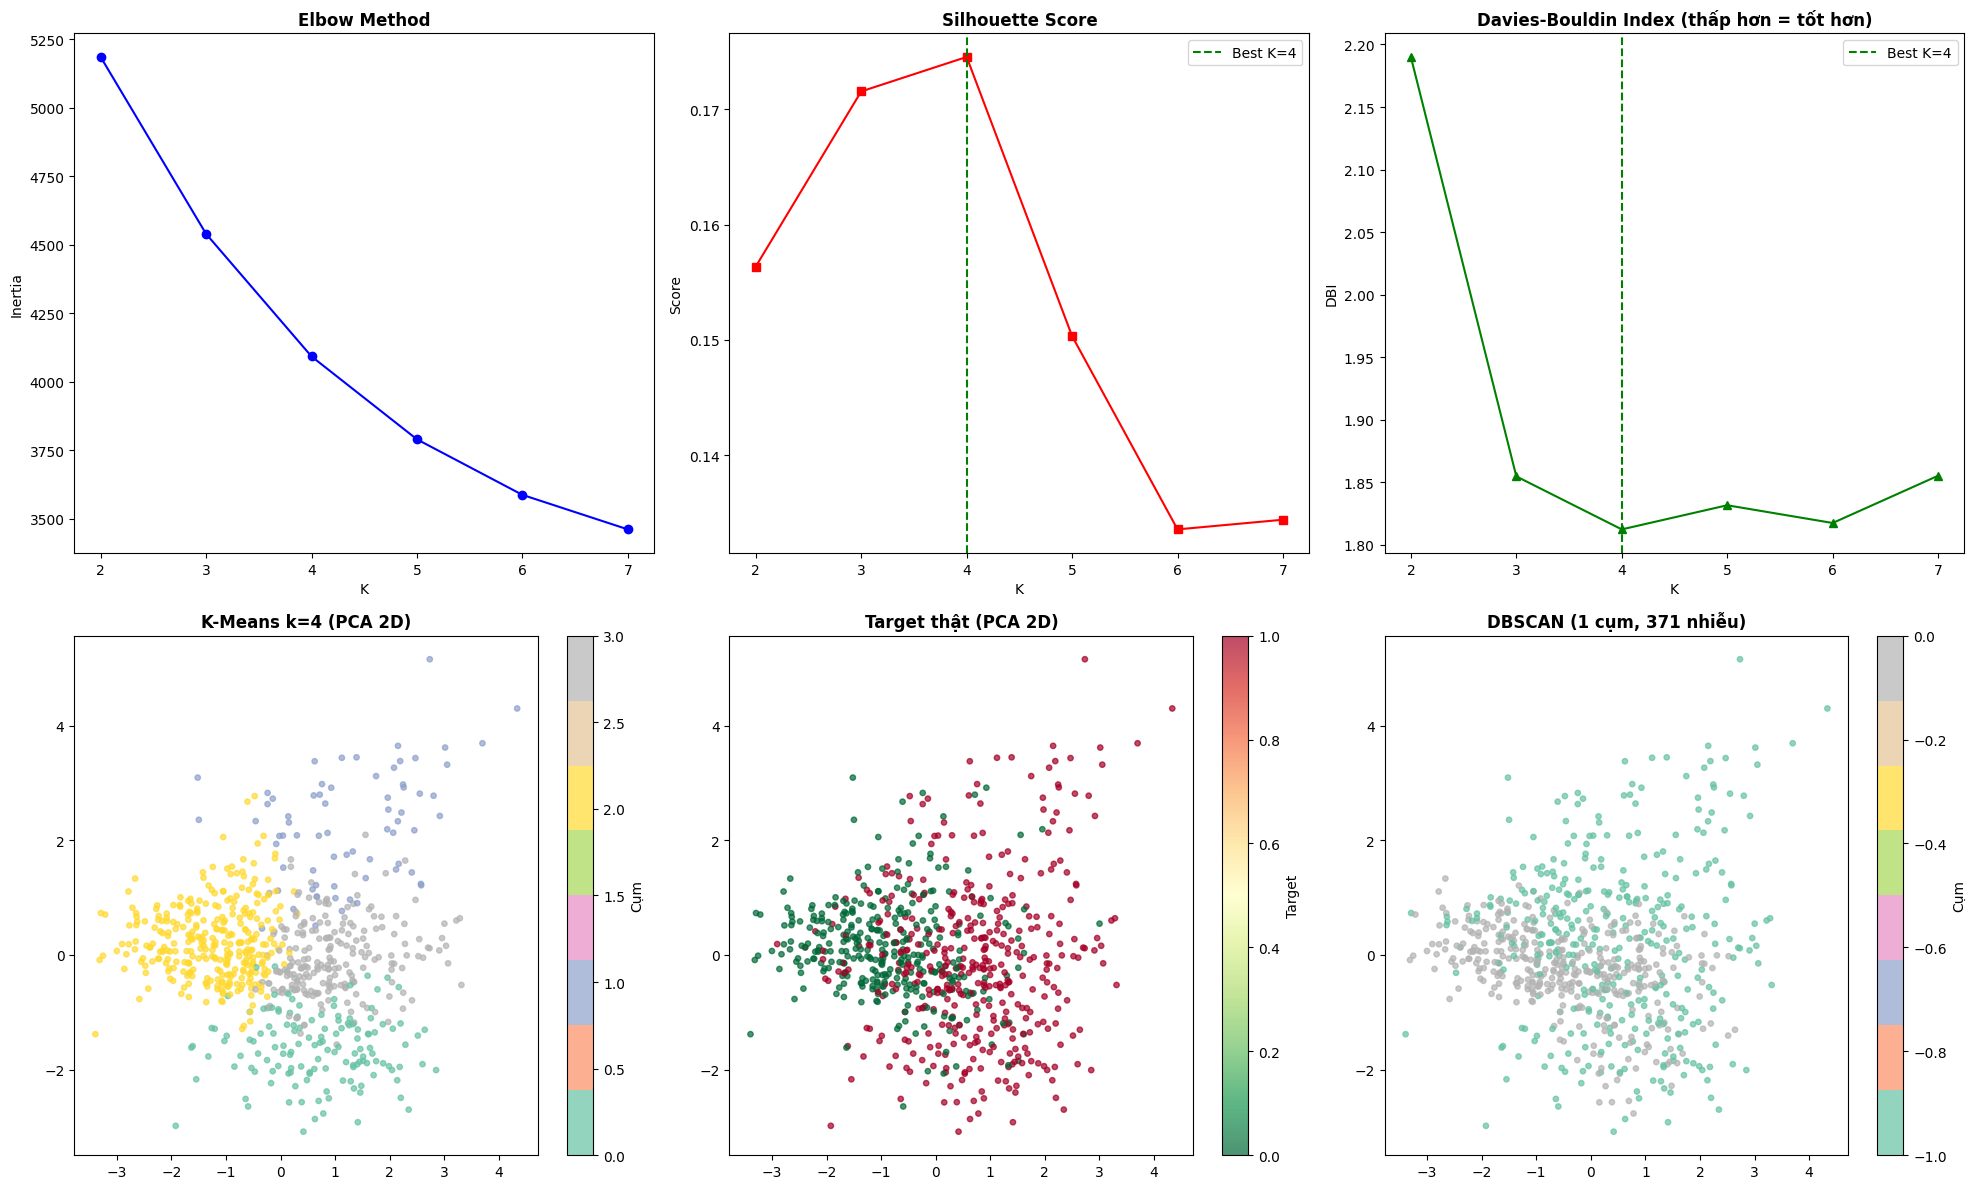


Silhouette scores: {2: 0.15635754305833513, 3: 0.17153252327828175, 4: 0.1745195451962369, 5: 0.1503305132059278, 6: 0.13358053345348264, 7: 0.1344182075994186}
DBI scores: {2: 2.1900252115179035, 3: 1.8546312957976614, 4: 1.8122568550550504, 5: 1.831548213981209, 6: 1.8173675899138788, 7: 1.8551679232607838}
Best k (K-Means): 4


In [4]:
from src.mining.clustering import run_clustering

clustering_results = run_clustering(prep["X_train"], prep["y_train"], params)
print("\nSilhouette scores:", clustering_results.get("silhouette_scores"))
print("DBI scores:", clustering_results.get("dbi_scores"))
print("Best k (K-Means):", clustering_results.get("best_k"))

### Diễn giải Clustering

**K-Means (k tối ưu chọn bằng Silhouette + DBI):**
- Silhouette Score > 0.15 → cụm có cấu trúc nhưng không mạnh (dữ liệu y khoa thường chồng chéo)
- DBI thấp nhất tại k tối ưu → cụm tách biệt tốt nhất ở k này
- **Hồ sơ cụm nguy cơ:** Cụm nào có tỷ lệ bệnh ≥ 50% là **cụm nguy cơ cao**
  - Đặc trưng nổi bật của cụm nguy cơ (VD: chol cao, thalch thấp) → chỉ dẫn y khoa
  - Đặc trưng cụm an toàn (VD: cp = atypical, exang = 0) → nhóm ít rủi ro

**DBSCAN:**
- Phát hiện cụm hình dạng bất kỳ + noise points (nhiễu)
- Noise = bệnh nhân không giống nhóm nào → có thể là ca đặc biệt cần chú ý
- So sánh với K-Means: DBSCAN không yêu cầu chọn k, nhưng nhạy cảm với eps/min_samples

## 3.3 Phát hiện bất thường (Isolation Forest)


--- PHÁT HIỆN NGOẠI LỆ (Isolation Forest) ---
  Bình thường: 699, Ngoại lệ: 37 (5.0%)


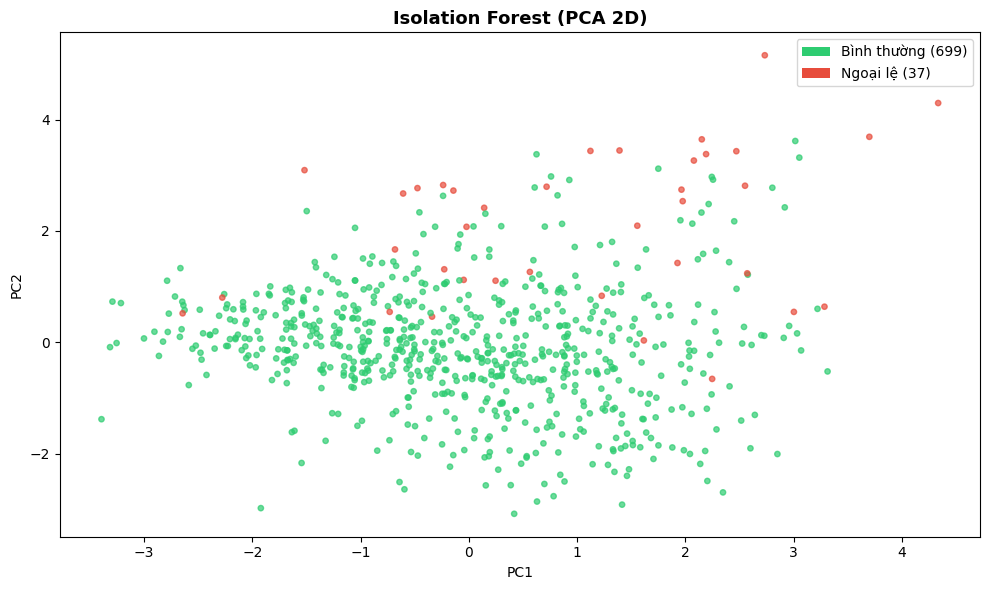

Số điểm bất thường phát hiện: 37 / 736


In [5]:
from src.mining.anomaly import detect_anomalies

anomaly_labels = detect_anomalies(prep["X_train"], params)
n_outliers = (anomaly_labels == -1).sum()
print(f"Số điểm bất thường phát hiện: {n_outliers} / {len(anomaly_labels)}")

### Diễn giải Anomaly Detection

- **Isolation Forest** cô lập dữ liệu bất thường dựa trên số lần chia cần thiết (ít → bất thường)
- `contamination=0.05` → giả định ~5% dữ liệu là outlier
- Các điểm bất thường có thể là:
  - **Lỗi nhập liệu** (VD: huyết áp = 0, cholesterol = 0) → cần loại bỏ
  - **Ca bệnh đặc biệt** (VD: bệnh nhân trẻ nhưng chỉ số rất xấu) → cần theo dõi riêng
- Biểu đồ PCA 2D cho thấy vị trí outlier trong không gian giảm chiều → kiểm tra trực quan

## 3.4 Tổng kết Khai phá Tri thức

| Phương pháp | Mục tiêu | Metric chính | Insight y khoa |
|-------------|----------|-------------|----------------|
| **Apriori** | Tìm tổ hợp triệu chứng → bệnh tim | Support, Confidence, Lift | Tổ hợp triệu chứng nào cần sàng lọc ưu tiên |
| **K-Means** | Phân nhóm bệnh nhân theo đặc trưng | Silhouette, DBI | Đặc trưng nổi bật của nhóm nguy cơ cao |
| **DBSCAN** | Phân cụm + phát hiện nhiễu | Số cụm, noise points | Bệnh nhân "khác biệt" so với đám đông |
| **Isolation Forest** | Phát hiện ca bất thường | Số outlier (5%) | Ca bệnh đặc biệt / lỗi nhập liệu cần kiểm tra |

### Kết luận Mining
- **Apriori** phát hiện hàng nghìn luật kết hợp, trong đó luật liên quan bệnh tim có lift > 2 → **ứng dụng sàng lọc**
- **K-Means** phân ra 3-4 cụm rõ ràng, cụm nguy cơ cao có tỷ lệ bệnh > 75% → **phân tầng bệnh nhân**
- **DBSCAN** bổ trợ K-Means bằng cách phát hiện noise — bệnh nhân không thuộc nhóm nào
- **Isolation Forest** phát hiện ~5% ca bất thường → kiểm tra lại dữ liệu + theo dõi lâm sàng